In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [2]:
np.random.seed(0)


In [3]:
# -------------------------
# 1. Prior p(z)
# -------------------------
z = np.linspace(-2, 2, 200)
prior = (1/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

# sample latent variables
N = 500
z_samples = np.random.normal(0, 1, N)


In [4]:
# -------------------------
# 2. Nonlinear mapping f(z)
# -------------------------
def f(z):
    x1 = z
    x2 = np.sin(2*z)
    return np.stack([x1, x2], axis=-1)

# latent -> mean in data space
mu = f(z_samples)


In [5]:
# -------------------------
# 3. Likelihood p(x|z)
# -------------------------
sigma = 0.2
x_samples = mu + sigma*np.random.randn(N,2)

# pick one latent point z*
z_star = 1.0
mu_star = f(z_star)

# grid for likelihood visualization
x1 = np.linspace(-3,3,200)
x2 = np.linspace(-3,3,200)
X1, X2 = np.meshgrid(x1,x2)
pos = np.dstack((X1,X2))

likelihood = multivariate_normal(mean=mu_star,
                                 cov=sigma**2*np.eye(2)).pdf(pos)


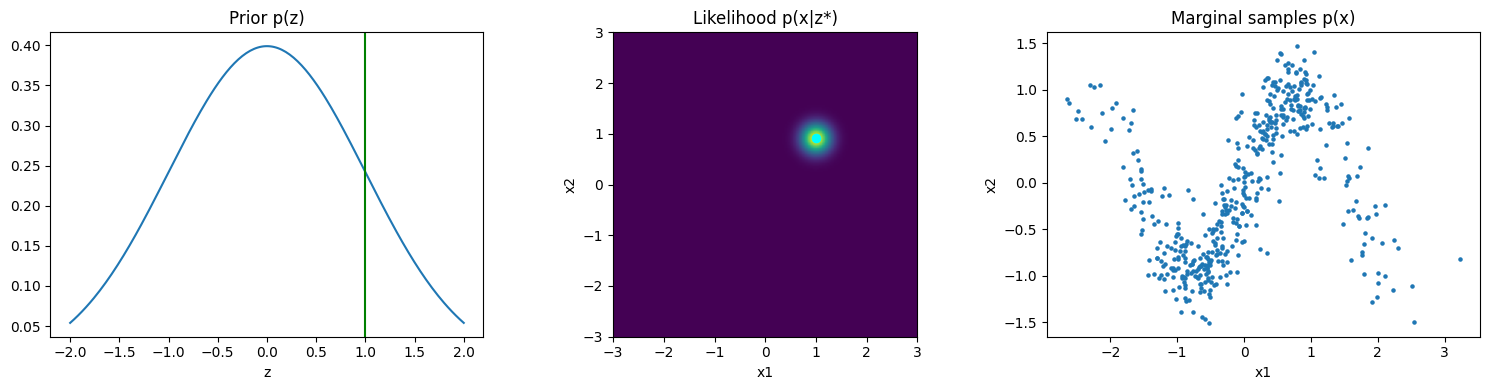

In [6]:
# -------------------------
# 4. Plot
# -------------------------
fig, ax = plt.subplots(1,3,figsize=(15,4))

# a) Prior
ax[0].plot(z, prior)
ax[0].axvline(z_star, color='green')
ax[0].set_title("Prior p(z)")
ax[0].set_xlabel("z")

# b) Likelihood p(x|z*)
ax[1].imshow(likelihood,
             extent=[x1.min(),x1.max(),x2.min(),x2.max()],
             origin="lower")
ax[1].scatter(mu_star[0], mu_star[1], c="cyan")
ax[1].set_title("Likelihood p(x|z*)")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")

# c) Marginal samples p(x)
ax[2].scatter(x_samples[:,0], x_samples[:,1], s=5)
ax[2].set_title("Marginal samples p(x)")
ax[2].set_xlabel("x1")
ax[2].set_ylabel("x2")

plt.tight_layout()
plt.show()
